In [ ]:
import numpy as np
import beyond21.global_wrapper as gw

##  Create GlobalWrapper Objects
Create a Beyond21 object using 
**`beyond21.global_wrapper.GlobalWrapper(...)`**

which takes **four parameter dictionaries**:

- `cosmo_params` *(dict, default = None)* 
- `star_formation_params` *(dict)*  
- `xray_params` *(dict)*  
- `reion_params` *(dict)*  

-Only the cosmo_params can be skipped in which case Planck18 cosmology and a ST HMF will be assumed.  
  -By default Beyond21 uses the Lyman-band spectra for PopII/PopIII provided in beyond21/data/uv_spectra 
  
---

Additional Optional Parameters:

- `lya_heat` *(bool, default = False)*  
  Set to **True** to include heating by **Lyman-alpha photons**
- `cmb_heat` *(bool, default = False)*  
  Set to **True** to include heating by **CMB**
- `photoheat` *(bool, default = False)*  
  Set to **True** to include photoheating feedback on Pop-III star formation

---
**PopIII stars** are activated by setting **star_formation_params['model'] == 'PopII+PopIII'**.  
  To run the example with PopIII change this and uncomment all PopIII parameters


 
  



In [2]:
# Set cosmological and astrophysical parameters
# - - - - - - - - - - - - - - - - - - - - - - - 

cosmo_params = {
    'Om0' : 0.3111,
    'Ob0' : 0.0490,
    'H0' : 67.66,
    'sigma8' : 0.8102,
    'ns' : 0.9665,
    'Neff' : 3.046,
    'Y_He' : 0.24, 
    'hmf_kwargs' : {"mdef": "fof", "model": "sheth99"}
    }

star_formation_params = {
                'model' : 'PopII+PopIII',   # To turn on PopIII, change to 'PopII+PopIII' and uncomment the PopIII parameters below.
                'M_cutII' : 2.7e7,
                'eps_t' : 0.38,
                'F_starII' : 1.2,
                'Mpivot' : 1.3e13,
                'alphaII' : -0.46,
                'betaII' : 0.6,
                'F_starIII' : 5.4e-3,
                'alphaIII' : -0.62,
                'M_cutIII' : 2.5e6,
                'A_LW' : 2,
                'B_LW' : 0.6,
                'A_vrel' : 1,
                'B_vrel' : 1.8
                }

xray_params = {
    'LSFRII' : 10**(40.5),
    'LSFRIII' : 10**(40.5),
    'E_min' : 0.5,
    'E_max' : 15,
    'alpha_s' : 1,
    'alpha_h' : 2.2,
    'E_break' : 2,
    }

reion_params = {
    'F_escII' : 2.5e-2,
    'alpha_escII' : -0.83,
    'N_ionII' : 5000,   
    'F_escIII' : 3.5e-3,
    'alpha_escIII' : -0.8,
    'N_ionIII' : 44000
}


# Initialize the global object and compute astrophysics history
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
GlobalObj = gw.GlobalWrapper(star_formation_params = star_formation_params, xray_params = xray_params, reion_params = reion_params,  Lya_Heat = False, CMB_Heat = False, photoheat = True)


/Users/omerkatz/Documents/research/CodePaper/PublicVersion/src/beyond21/global_wrapper.py:101: UserWarning: No cosmo_params given. Assuming Planck18 cosmology and ST HMF.
  warnings.warn(



## Run IGM Evolution

To compute IGM properties run  **`GlobalWrapper.EvolveSM(...)`**

This function accepts up to **four optional arguments**:

- `z_min` *(float, default = 6)*  
  Minimum redshift at which the evolution ends. Very small values may cause errors for extreme models.

- `z_max` *(float, default = 1200)*  
  Redshift at which the evolution begins. Must be greater than 1200.

- `Npoints` *(int, default = 250)*  
  Number of output points, sampled uniformly in the logarithm of the scale factor:  
  `np.linspace(np.log(1 / (1 + z_max)), np.log(1 / (1 + z_min)), Npoints)`

- `ivp_kwarges` *(dict, default = {"rtol":1e-4,"max_step":0.01})*  
  kwargs for solve_ivp  


In [3]:
# Run IGM evolution from z = 1200 to z = 4
# - - - - - - - - - - - - - - - - - - - - -
GlobalObj.EvolveIGM(z_min = 6, z_max = 1200, Npoints = 250, ivp_kwargs = {"rtol":1e-4,"max_step":0.01})


<h1 style="text-align: center;"> Output Data and Plotting</h1>

<h2 style="text-align: center;"> Part A - IGM Evolution </h1>


## Retrieve Data Arrays

After running EvolveIGM the following arrays are available

In [4]:
rs = GlobalObj.rs            # Array of redshift values (1 + z)

# Temperatures
T21 = GlobalObj.T21          # T21 signal in Kelvin
Tbaryon = GlobalObj.Tbaryon  # baryon temperature in Kelvin
Tspin = GlobalObj.Tspin      # spin temperature in Kelvin
TCMB = GlobalObj.TCMB        # CMB temperature in Kelvin

# Hydrogen ionization
xHI = GlobalObj.xHI          # neutral hydrogen fraction
tau = GlobalObj.tau          # CMB optical depth to reionization

## Built in Plotting Functions

You can also visualize the above quantities directly using the built-in plotting
functions, without accessing the underlying data arrays.

All plotting functions follow a consistent interface and accept two optional arguments:

- `axis` (matplotlib axis, optional)  
  Existing matplotlib axis to plot on. If not provided, a new figure and axis
  will be created automatically.

- `**plot_kwargs` (optional)  
  Keyword arguments passed to axis.plot() (e.g., linewidth, linestyle,
  color, etc.), allowing full customization of the plot appearance.

### Global 21-cm evolution

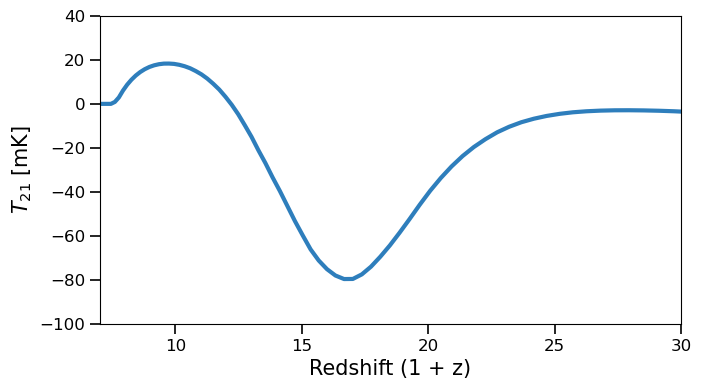

In [106]:
# (Optional) Customize plot appearance using standard matplotlib keyword arguments passed to ax.plot
plot_kwargs = {'color': 'blue', 'linestyle': 'solid', 'linewidth': 3}

# Running plotting function
fig,ax = GlobalObj.plot_T21()

# (Optional) Further customize the axes using standard matplotlib commands
ax.set_xlim(7,30)
ax.set_ylim(-100,40)
ax.set_xscale('linear')

### Combined evolution: baryon (Kinetic), hydrogen spin, and CMB temperatures

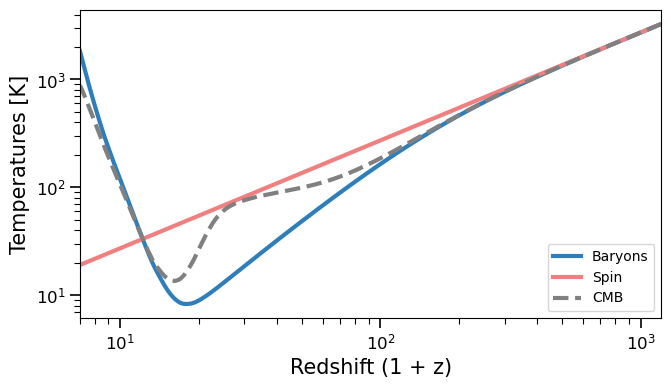

In [85]:
# Baryon Temperature Plotting function
plot_kwargs = {'label' : 'Baryons'}
fig,ax = GlobalObj.plot_Tbaryon(**plot_kwargs)

# CMB Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'Spin', 'color' : 'lightcoral'}
GlobalObj.plot_TCMB(axis = ax, **plot_kwargs)

# Spin Temperature Plotting function - Plot on the same axis
plot_kwargs = {'label' : 'CMB', 'color' : 'grey', 'linestyle' : 'dashed'}
GlobalObj.plot_Tspin(axis = ax, **plot_kwargs)

# Style axis
ax.set_ylabel('Temperatures [K]')
ax.legend()

### Neutral Hydrogen Fraction Evolution

Text(7.2, 0.95, '$\\tau_{\\rm e} = 0.054$')

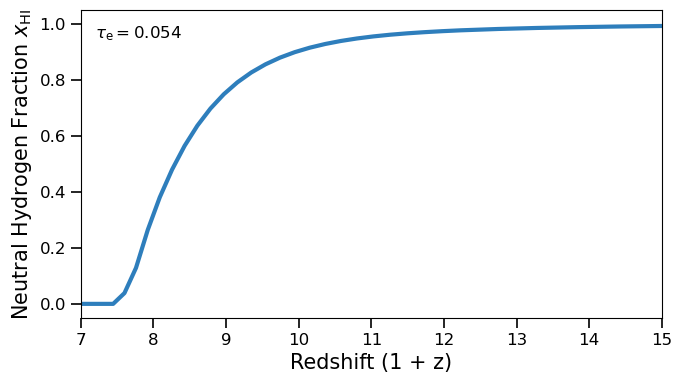

In [86]:
# Running plotting function
fig,ax = GlobalObj.plot_xHI()

# style axis
ax.set_yscale('linear')
ax.set_xscale('linear')
ax.set_xlim(7,15)

# Display the optical depth to reionization on the plot
ax.text(7.2, 0.95, rf'$\tau_{{\rm e}} = {tau:.3f}$', fontsize=12)

#

<h2 style="text-align: center;">Part B: Star Formation and UVLFs</h2>


### Star Formation Rate Density (SFRD)

The star formation rate density (SFRD) at a given redshift `z` is accessed through the method **`GlobalWrapper.SFRD(z)`**.

The SFRD is returned in units of $\left[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{Mpc}^{-3}\right]$.

**Notes**

- If two stellar populations are modeled, the method returns an array containing
  the individual contributions from Pop II and Pop III stars:
  $[\,\mathrm{SFRD}_{\mathrm{II}}(z),\,\mathrm{SFRD}_{\mathrm{III}}(z)\,]$.

- The SFRD is only defined for redshifts $z < z_\star$, where the default value
  is $z_\star = 50$.

In [87]:
z = 10
SFRD = GlobalObj.SFRD(z)

There is also a dedicated SFRD plotting function

Line styling is currently unavailable for two populations. Sorry for the inconvenience. 
If needed it is possible to change styling directly in plot_SFRD.


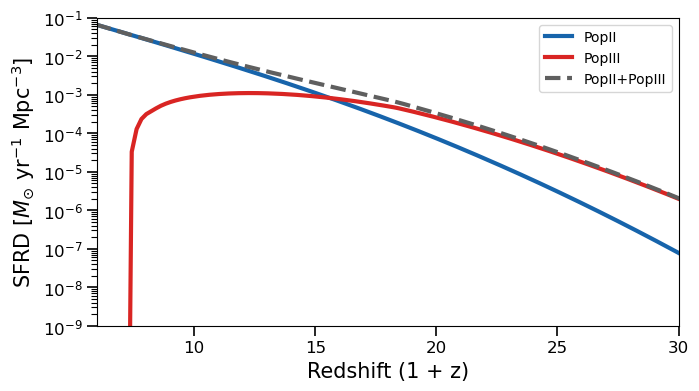

In [88]:
fig, ax = GlobalObj.plot_SFRD()

ax.set_xlim(6,30)
ax.set_ylim(1e-9,1e-1)
ax.legend()

### UV Luminosity Function (UVLF) 

The UV luminosity function (UVLF) at a given redshift `z` and magnitude `mag` is accessed through the method **`GlobalWrapper.UVLF(z, Mag)`**

The UVLF is returned in units of $\left[\mathrm{Mag}^{-1}\,\mathrm{Mpc}^{-3}\right]$.

**Notes**

- If two stellar populations are modeled, the method returns an array
  containing the contributions from Pop II– and Pop III–dominated galaxies:
  $[\,\Phi_{\mathrm{II}}(z),\,\Phi_{\mathrm{III}}(z)\,]$.

- The UVLF is only defined for redshifts $z < z_\star$, where the default value
  is $z_\star = 50$.

There is also a dedicated UVLF plotting function

Line styling is currently unavailable for two populations. Sorry for the inconvenience. 
If needed it is possible to change styling directly in plot_SFRD.


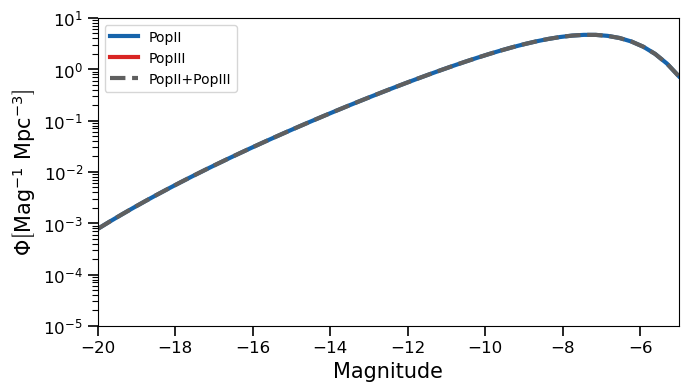

In [98]:
fig,ax = GlobalObj.plot_UVLF(6, MagArr = np.linspace(-20,-5, 50), sigma_MUV = 0.01, kUV=1.15e-28)
ax.set_ylim(1e-5,10)
ax.legend()

<h2 style="text-align: center;">Part C: Radiation Backgrounds</h2>


### Cosmic X-ray Background (CXB)

The contribution to the CXB [eV/cm^2/sec/sr] can be conveniently calculated using the method T21_obj.Xray_obj.XrayIntensity_noTau.


In [44]:
#CXB in eV/cm^2/sec/sr
z_unresolved = 4
print(str(GlobalObj.Xray_obj.CXB(z_unresolved,0.5,2)) + ' [eV/cm^2/sec/sr] ')

0.1449896605562154 [eV/cm^2/sec/sr] 
